In [2]:
!mkdir -p benchmark-results
!cd .. && timeout 120s ./build-release/bin/benchmarks --benchmark_filter='^BM_SQL<(InterpretedExpressionExecutor|CachedJitCompiledExpressionExecutor), (kSimpleSelectSmall|kJoinSmall|kComplex5), PlannerMode::(kNaive|kOptimized)>/real_time$' --benchmark_repetitions=3 --benchmark_display_aggregates_only=true --benchmark_out=research/benchmark-results/query.json --benchmark_out_format=json

2026-06-02T01:16:13+03:00
Running ./build-release/bin/benchmarks
Run on (8 X 4200 MHz CPU s)
CPU Caches:
  L1 Data 48 KiB (x4)
  L1 Instruction 32 KiB (x4)
  L2 Unified 1280 KiB (x4)
  L3 Unified 8192 KiB (x1)
Load Average: 0.38, 0.38, 0.46
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.
----------------------------------------------------------------------------------------------------------------------------------------------------
Benchmark                                                                                                          Time             CPU   Iterations
----------------------------------------------------------------------------------------------------------------------------------------------------
BM_SQL<InterpretedExpressionExecutor, kSimpleSelectSmall, PlannerMode::kNaive>/real_time_mean                  22492 ns        22349 ns            3
BM_SQL<InterpretedExpressionExecutor, kSimpl

In [3]:
!cd .. && SSB_DATA_DIR=benchmarks/datasets/ssb/generated/sf001 timeout 180s ./build-release/bin/benchmarks --benchmark_filter='^SSB/' --benchmark_repetitions=3 --benchmark_display_aggregates_only=true --benchmark_out=research/benchmark-results/ssb-sf001.json --benchmark_out_format=json

2026-06-02T01:16:41+03:00
Running ./build-release/bin/benchmarks
Run on (8 X 4200 MHz CPU s)
CPU Caches:
  L1 Data 48 KiB (x4)
  L1 Instruction 32 KiB (x4)
  L2 Unified 1280 KiB (x4)
  L3 Unified 8192 KiB (x1)
Load Average: 0.80, 0.49, 0.49
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.
----------------------------------------------------------------------------------------------------------
Benchmark                                                Time             CPU   Iterations UserCounters...
----------------------------------------------------------------------------------------------------------
SSB/q2.1/Interpreted/Naive/real_time_mean          9535917 ns      9457917 ns            3 execution_us=9.53583k includes_order_by=1
SSB/q2.1/Interpreted/Naive/real_time_median        9539993 ns      9459233 ns            3 execution_us=9.53993k includes_order_by=1
SSB/q2.1/Interpreted/Naive/real_time_stddev          

In [4]:
!cd .. && timeout 300s ./build-release/bin/benchmarks --benchmark_filter='^OperatorCost/' --benchmark_repetitions=3 --benchmark_display_aggregates_only=true --benchmark_out=research/benchmark-results/operator-cost.json --benchmark_out_format=json

2026-06-02T01:17:41+03:00
Running ./build-release/bin/benchmarks
Run on (8 X 4200 MHz CPU s)
CPU Caches:
  L1 Data 48 KiB (x4)
  L1 Instruction 32 KiB (x4)
  L2 Unified 1280 KiB (x4)
  L3 Unified 8192 KiB (x1)
Load Average: 1.43, 0.74, 0.58
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.
----------------------------------------------------------------------------------------------------------------------
Benchmark                                                            Time             CPU   Iterations UserCounters...
----------------------------------------------------------------------------------------------------------------------
OperatorCost/SeqScan/1024/real_time_mean                         38473 ns        38210 ns            3 model_cost=102.4k output_rows=1.024k plan_cost=102.4k rows=1.024k
OperatorCost/SeqScan/1024/real_time_median                       38428 ns        38240 ns            3 model_cost=

In [5]:
!cd .. && timeout 300s ./build-release/bin/benchmarks --benchmark_filter='^OperatorCostMatched/' --benchmark_repetitions=3 --benchmark_display_aggregates_only=true --benchmark_out=research/benchmark-results/operator-cost-matched.json --benchmark_out_format=json

2026-06-02T01:20:14+03:00
Running ./build-release/bin/benchmarks
Run on (8 X 4200 MHz CPU s)
CPU Caches:
  L1 Data 48 KiB (x4)
  L1 Instruction 32 KiB (x4)
  L2 Unified 1280 KiB (x4)
  L3 Unified 8192 KiB (x1)
Load Average: 1.60, 1.07, 0.73
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.
------------------------------------------------------------------------------------------------------------------------------------------------
Benchmark                                                                                      Time             CPU   Iterations UserCounters...
------------------------------------------------------------------------------------------------------------------------------------------------
OperatorCostMatched/target_cost:640000/SeqScan/6400/real_time_mean                        320159 ns       317346 ns            3 model_cost=640k output_rows=6.4k plan_cost=640k rows=6.4k
OperatorCostMatche

In [6]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

RESULTS = Path("benchmark-results")
UNIT_TO_MS = {"ns": 1e-6, "us": 1e-3, "ms": 1.0, "s": 1e3}

def mean_rows(filename):
    data = json.loads((RESULTS / filename).read_text())
    return [row for row in data["benchmarks"] if row.get("aggregate_name") == "mean"]

def time_ms(row):
    return row["real_time"] * UNIT_TO_MS[row["time_unit"]]

In [7]:
synthetic_pattern = re.compile(
    r"BM_SQL<(?P<executor>[^,]+), (?P<query>[^,]+), PlannerMode::k(?P<mode>[^>]+)>/real_time_mean"
)
synthetic = []
for row in mean_rows("query.json"):
    match = synthetic_pattern.fullmatch(row["name"])
    synthetic.append({**match.groupdict(), "time_ms": time_ms(row)})
synthetic = pd.DataFrame(synthetic)

ssb = []
for row in mean_rows("ssb-sf001.json"):
    _, query, executor, mode, _ = row["name"].split("/")
    ssb.append({"query": query, "executor": executor, "mode": mode, "time_ms": time_ms(row)})
ssb = pd.DataFrame(ssb)

synthetic, ssb

(                               executor               query       mode  \
 0         InterpretedExpressionExecutor  kSimpleSelectSmall      Naive   
 1         InterpretedExpressionExecutor  kSimpleSelectSmall  Optimized   
 2   CachedJitCompiledExpressionExecutor  kSimpleSelectSmall      Naive   
 3   CachedJitCompiledExpressionExecutor  kSimpleSelectSmall  Optimized   
 4         InterpretedExpressionExecutor          kJoinSmall      Naive   
 5         InterpretedExpressionExecutor          kJoinSmall  Optimized   
 6   CachedJitCompiledExpressionExecutor          kJoinSmall      Naive   
 7   CachedJitCompiledExpressionExecutor          kJoinSmall  Optimized   
 8         InterpretedExpressionExecutor           kComplex5      Naive   
 9         InterpretedExpressionExecutor           kComplex5  Optimized   
 10  CachedJitCompiledExpressionExecutor           kComplex5      Naive   
 11  CachedJitCompiledExpressionExecutor           kComplex5  Optimized   
 
      time_ms  
 0   0.

In [8]:
operator = []
for row in mean_rows("operator-cost.json"):
    parts = row["name"].split("/")
    operator.append({
        "operator": parts[1],
        "input_rows": max(map(int, parts[2:-1])),
        "model_cost": row["model_cost"],
        "time_ms": time_ms(row),
    })
operator = pd.DataFrame(operator)

matched = []
for row in mean_rows("operator-cost-matched.json"):
    parts = row["name"].split("/")
    matched.append({
        "target_cost": int(parts[1].split(":")[1]),
        "operator": parts[2],
        "input_rows": max(map(int, parts[3:-1])),
        "model_cost": row["model_cost"],
        "time_ms": time_ms(row),
    })
matched = pd.DataFrame(matched)

operator, matched

(               operator  input_rows   model_cost     time_ms
 0               SeqScan        1024     102400.0    0.038473
 1               SeqScan        2048     204800.0    0.069707
 2               SeqScan        4096     409600.0    0.154163
 3               SeqScan        8192     819200.0    0.390148
 4               SeqScan       16384    1638400.0    0.924368
 ..                  ...         ...          ...         ...
 59  NestedLoopCrossJoin          64     425984.0    0.288639
 60  NestedLoopCrossJoin         128    1703936.0    0.899354
 61  NestedLoopCrossJoin         256    6815744.0    5.036885
 62  NestedLoopCrossJoin         512   27262976.0   25.155229
 63  NestedLoopCrossJoin        1024  109051904.0  125.736836
 
 [64 rows x 4 columns],
     target_cost             operator  input_rows  model_cost     time_ms
 0        640000              SeqScan        6400    640000.0    0.320159
 1        640000               Filter        6400    640000.0    0.409248
 2      

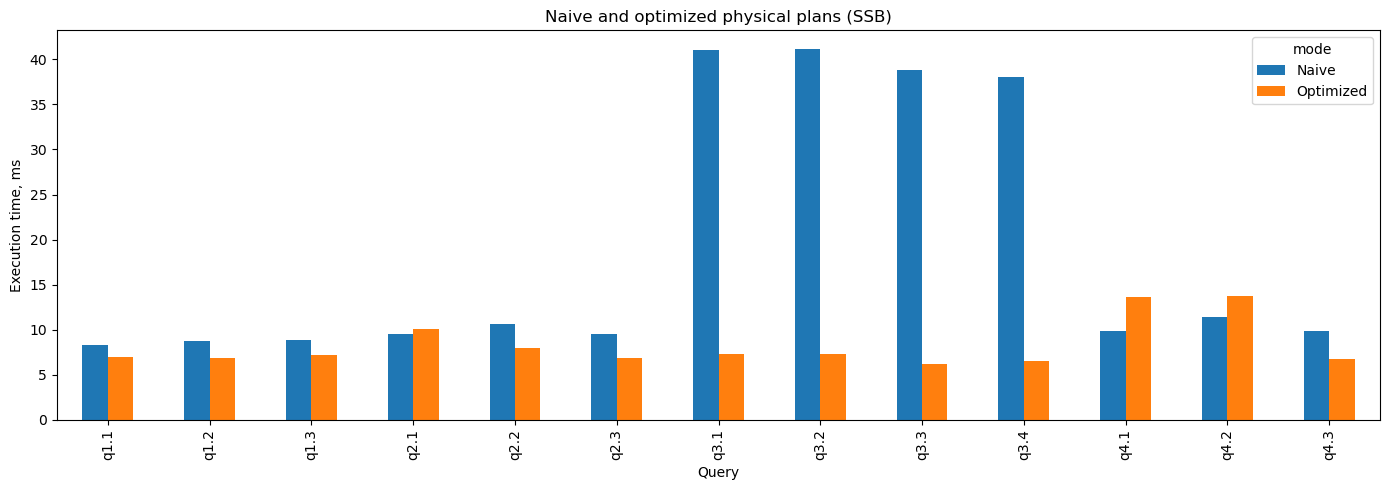

In [15]:
ssb_interpreted = ssb[ssb.executor == "Interpreted"].copy()

wide = ssb_interpreted.pivot(index="query", columns="mode", values="time_ms").sort_index()
ax = wide[["Naive", "Optimized"]].plot.bar(figsize=(14, 5))
ax.set_ylabel("Execution time, ms")
ax.set_xlabel("Query")
ax.set_title("Naive and optimized physical plans (SSB)")
plt.tight_layout()

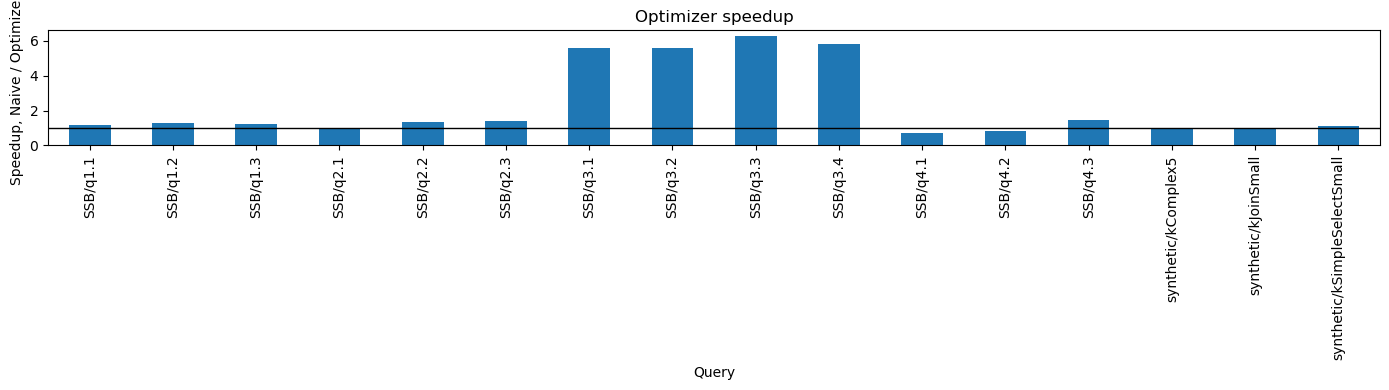

In [10]:
speedup = (wide["Naive"] / wide["Optimized"]).sort_index()
ax = speedup.plot.bar(figsize=(14, 4))
ax.axhline(1.0, color="black", linewidth=1)
ax.set_ylabel("Speedup, Naive / Optimized")
ax.set_xlabel("Query")
ax.set_title("Optimizer speedup")
plt.tight_layout()

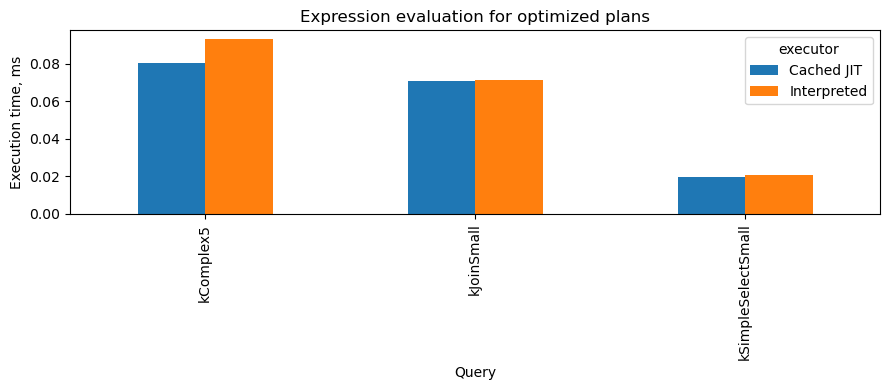

In [11]:
jit = synthetic[synthetic["mode"] == "Optimized"].copy()
jit["executor"] = jit["executor"].replace({
    "InterpretedExpressionExecutor": "Interpreted",
    "CachedJitCompiledExpressionExecutor": "Cached JIT",
})
ax = jit.pivot(index="query", columns="executor", values="time_ms").plot.bar(figsize=(9, 4))
ax.set_ylabel("Execution time, ms")
ax.set_xlabel("Query")
ax.set_title("Expression evaluation for optimized plans")
plt.tight_layout()

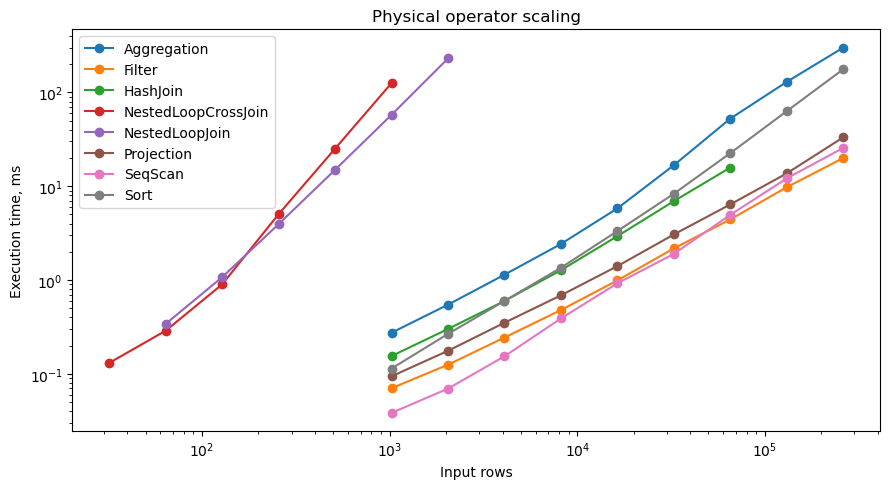

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, group in operator.groupby("operator"):
    group = group.sort_values("input_rows")
    ax.plot(group.input_rows, group.time_ms, marker="o", label=name)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Input rows")
ax.set_ylabel("Execution time, ms")
ax.set_title("Physical operator scaling")
ax.legend()
plt.tight_layout()

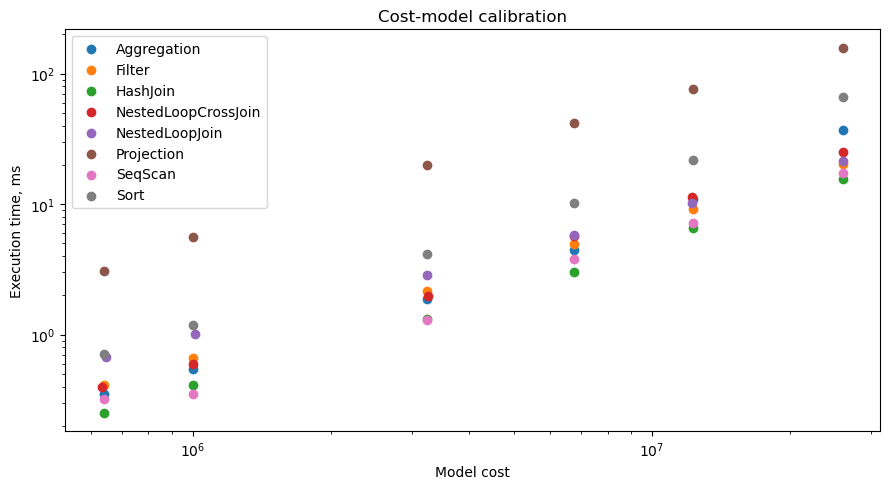

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
for name, group in matched.groupby("operator"):
    ax.scatter(group.model_cost, group.time_ms, label=name)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Model cost")
ax.set_ylabel("Execution time, ms")
ax.set_title("Cost-model calibration")
ax.legend()
plt.tight_layout()

In [14]:
coefficients = pd.DataFrame([
    ("SeqScan", "row", 100),
    ("Filter", "output row", 100),
    ("Projection", "output row", 22),
    ("Sort", "n * (floor(log2(n)) + 1)", 11),
    ("Aggregation", "input row", 510),
    ("NestedLoopJoin", "input row pair", 70),
    ("NestedLoopCrossJoin", "input row pair", 104),
    ("HashJoin", "build row * width", 100),
    ("HashJoin", "probe row", 35),
    ("HashJoin", "output row * width", 10),
], columns=["operator", "coefficient", "value"])
coefficients

,operator,coefficient,value
0,SeqScan,row,100
1,Filter,output row,100
2,Projection,output row,22
3,Sort,n * (floor(log2(n)) + 1),11
4,Aggregation,input row,510
5,NestedLoopJoin,input row pair,70
6,NestedLoopCrossJoin,input row pair,104
7,HashJoin,build row * width,100
8,HashJoin,probe row,35
9,HashJoin,output row * width,10
